**Jakub Orchowski, s223281**

# CEL ĆWICZENIA
Kreślenie krzywych na obrazie zdyskretyzowanym oraz aproksymacja zbiorów punktów metodą najmniejszych kwadratów.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

# Zadania

## Zadanie 1.
Na obrazie o rozdzielczości 640x480 rysuję krzywą $y = A\sqrt{x}$ dla kilku dodatnich wartości parametru $A$.
Konstrukcja wykorzystuje operacje całkowitoliczbowe i łączy kolejne próbki odcinkami Bresenhama, dzięki czemu zachowuje ciągłość także dla stromego początku krzywej.

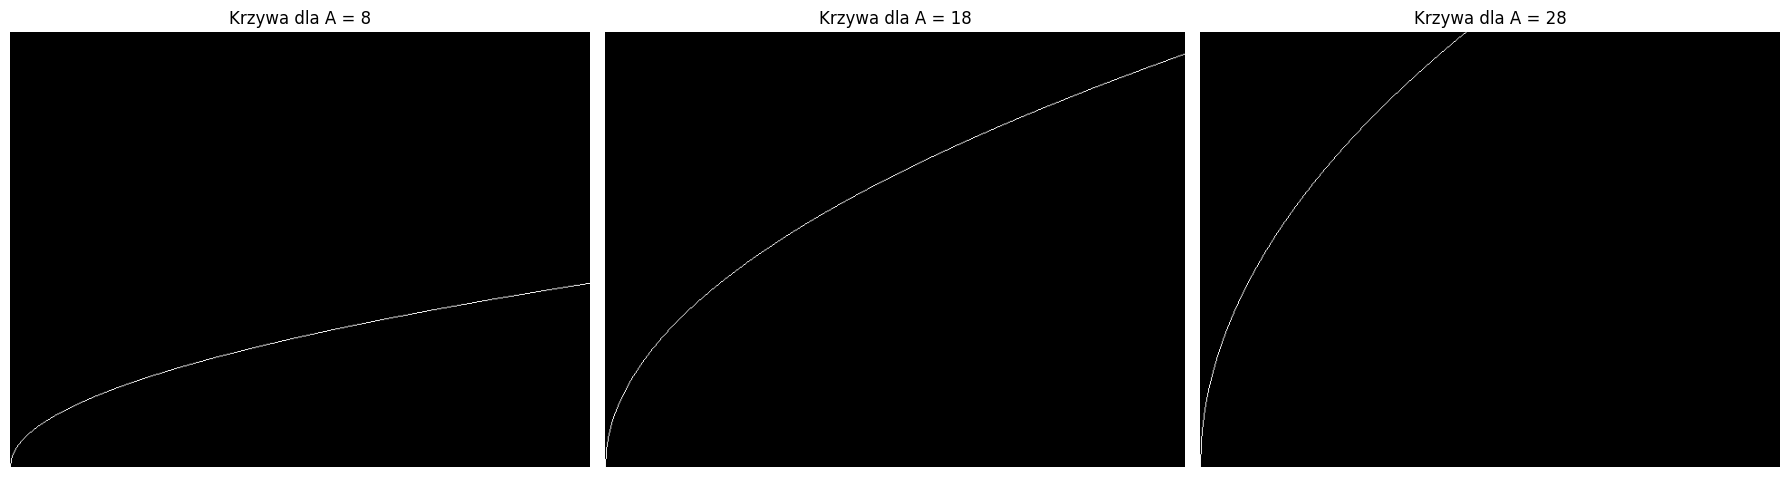

A = 8: ostatni widoczny punkt ma wspolrzedne (x, y) = (639, 202), a liczba zapalonych pikseli wynosi 656.
A = 18: ostatni widoczny punkt ma wspolrzedne (x, y) = (639, 455), a liczba zapalonych pikseli wynosi 721.
A = 28: ostatni widoczny punkt ma wspolrzedne (x, y) = (293, 479), a liczba zapalonych pikseli wynosi 490.


In [2]:
IMAGE_WIDTH = 640
IMAGE_HEIGHT = 480
A_VALUES = [8, 18, 28]


def draw_bresenham_line(image: np.ndarray, start: tuple[int, int], end: tuple[int, int], value: int = 255) -> None:
    """Rysuje odcinek w przestrzeni pikselowej wyłącznie operacjami całkowitoliczbowymi."""
    x0, y0 = start
    x1, y1 = end
    dx = abs(x1 - x0)
    sx = 1 if x0 < x1 else -1
    dy = -abs(y1 - y0)
    sy = 1 if y0 < y1 else -1
    error = dx + dy

    while True:
        if 0 <= x0 < image.shape[1] and 0 <= y0 < image.shape[0]:
            image[y0, x0] = value
        if x0 == x1 and y0 == y1:
            break
        doubled_error = 2 * error
        if doubled_error >= dy:
            error += dy
            x0 += sx
        if doubled_error <= dx:
            error += dx
            y0 += sy


def math_to_image_point(x: int, y: int, height: int) -> tuple[int, int]:
    """Zamienia wspolrzedne matematyczne na pikselowe przy odwroconej osi Y."""
    return x, height - 1 - y


def rasterize_sqrt_curve(width: int, height: int, a: int, value: int = 255) -> tuple[np.ndarray, np.ndarray]:
    """Rasteryzuje krzywa y = a * sqrt(x) bez uzycia liczb zmiennoprzecinkowych."""
    if a <= 0:
        raise ValueError('Parametr a musi byc dodatni.')

    image = np.zeros((height, width), dtype=np.uint8)
    sampled_points: list[tuple[int, int]] = []
    a_squared = a * a
    y = 0
    previous_pixel: tuple[int, int] | None = None

    for x in range(width):
        target = 4 * a_squared * x
        while (2 * y + 1) * (2 * y + 1) <= target:
            y += 1

        sampled_points.append((x, y))
        pixel = math_to_image_point(x, y, height)

        if previous_pixel is None:
            if 0 <= pixel[0] < width and 0 <= pixel[1] < height:
                image[pixel[1], pixel[0]] = value
        else:
            draw_bresenham_line(image, previous_pixel, pixel, value)

        previous_pixel = pixel
        if y >= height:
            break

    return image, np.array(sampled_points, dtype=np.int64)


fig, axes = plt.subplots(1, len(A_VALUES), figsize=(18, 5))
curve_summaries = []

for ax, a in zip(axes, A_VALUES):
    image, sampled_points = rasterize_sqrt_curve(IMAGE_WIDTH, IMAGE_HEIGHT, a)
    visible_points = sampled_points[sampled_points[:, 1] < IMAGE_HEIGHT]
    last_visible_x, last_visible_y = visible_points[-1]
    ax.imshow(image, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Krzywa dla A = {a}')
    ax.axis('off')
    curve_summaries.append((a, int(last_visible_x), int(last_visible_y), int(np.count_nonzero(image))))

plt.tight_layout()
plt.show()

for a, last_visible_x, last_visible_y, pixel_count in curve_summaries:
    print(
        f'A = {a}: ostatni widoczny punkt ma wspolrzedne (x, y) = ({last_visible_x}, {last_visible_y}), '
        f'a liczba zapalonych pikseli wynosi {pixel_count}.'
    )

### Wnioski
Całkowitoliczbowe kryterium doboru kolejnej próbki pozwala narysować krzywą bez użycia pierwiastka i bez rachunku zmiennoprzecinkowego.
Łączenie kolejnych punktów odcinkami Bresenhama usuwa przerwy przy stromym początku, a dla dużych wartości A algorytm poprawnie obcina fragment wychodzący poza obraz.

## Zadanie 2.
Dla kilku uporządkowanych zbiorów punktów wyznaczam aproksymację najmniejszych kwadratów modelem $y = a + b\sin x + cx^2$.
Ponieważ współczynniki występują liniowo, problem sprowadza się do rozwiązania układu dla macierzy projektującej z bazą $[1, \sin x, x^2]$.

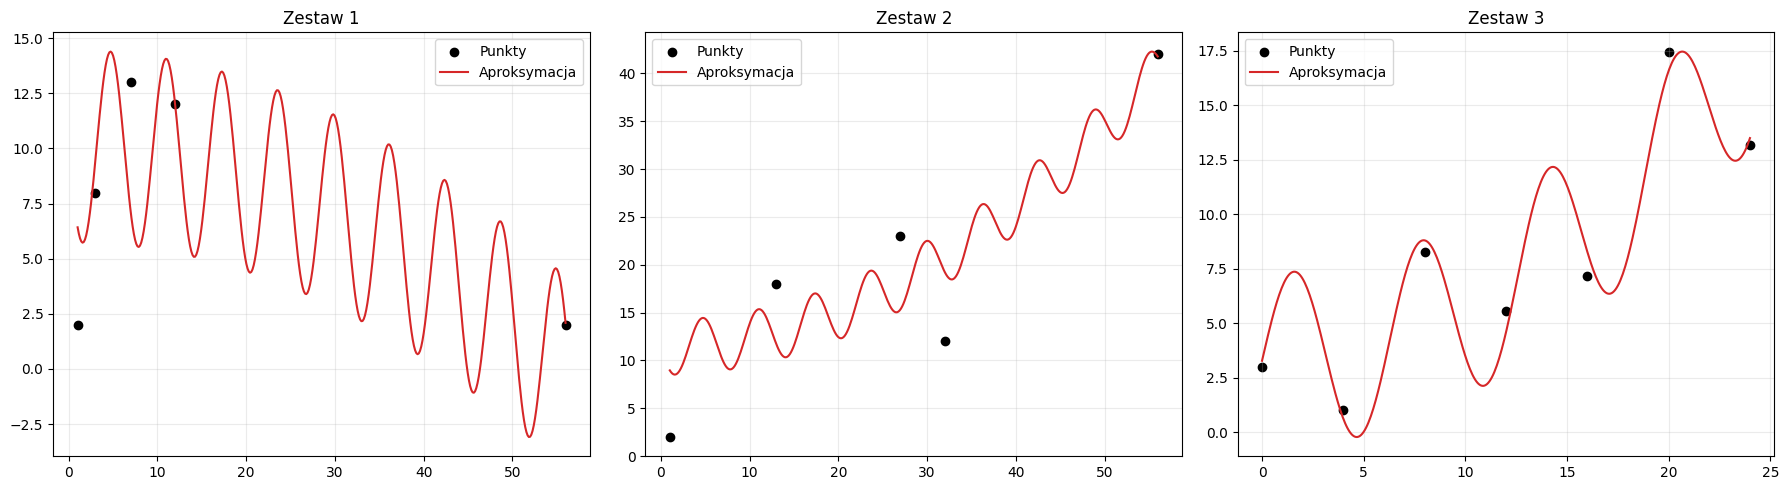

Zestaw 1: a = 10.0981, b = -4.3655, c = -0.003280, MSE = 11.3681
Zestaw 2: a = 11.3672, b = -2.8696, c = 0.009214, MSE = 39.7571
Zestaw 3: a = 3.2803, b = 4.0260, c = 0.024063, MSE = 0.4960


In [3]:
def build_design_matrix(x: np.ndarray, basis_functions: list) -> np.ndarray:
    """Buduje macierz projektujaca dla zadanego zestawu funkcji bazowych."""
    return np.column_stack([basis_function(x) for basis_function in basis_functions]).astype(np.float64)


def fit_linear_model(x: np.ndarray, y: np.ndarray, basis_functions: list) -> tuple[np.ndarray, np.ndarray, float]:
    """Wyznacza parametry modelu liniowego oraz blad sredniokwadratowy."""
    design_matrix = build_design_matrix(x, basis_functions)
    coefficients, _, _, _ = np.linalg.lstsq(design_matrix, y, rcond=None)
    fitted_values = design_matrix @ coefficients
    mse = float(np.mean((y - fitted_values) ** 2))
    return coefficients, fitted_values, mse


def evaluate_linear_model(x: np.ndarray, coefficients: np.ndarray, basis_functions: list) -> np.ndarray:
    """Oblicza wartosci modelu dla nowego wektora argumentow."""
    return build_design_matrix(x, basis_functions) @ coefficients


def plot_approximation(ax, x: np.ndarray, y: np.ndarray, coefficients: np.ndarray, basis_functions: list, title: str) -> None:
    """Rysuje punkty i dopasowana krzywa dla wybranego modelu."""
    dense_x = np.linspace(x.min(), x.max(), 400)
    dense_y = evaluate_linear_model(dense_x, coefficients, basis_functions)
    ax.scatter(x, y, color='black', label='Punkty')
    ax.plot(dense_x, dense_y, color='tab:red', label='Aproksymacja')
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()


synthetic_x = np.array([0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 24.0], dtype=np.float64)
synthetic_y = 3.0 + 4.2 * np.sin(synthetic_x) + 0.025 * synthetic_x ** 2 + np.array([0.0, 0.8, -0.5, 1.2, -1.0, 0.6, -0.4])

datasets_approximation = [
    ('Zestaw 1', np.array([(1, 2), (3, 8), (7, 13), (12, 12), (56, 2)], dtype=np.float64)),
    ('Zestaw 2', np.array([(1, 2), (13, 18), (27, 23), (32, 12), (56, 42)], dtype=np.float64)),
    ('Zestaw 3', np.column_stack([synthetic_x, synthetic_y])),
]

basis_task2 = [
    lambda values: np.ones_like(values, dtype=np.float64),
    np.sin,
    lambda values: values ** 2,
]

fig, axes = plt.subplots(1, len(datasets_approximation), figsize=(18, 5))
task2_results = []

for ax, (name, points) in zip(axes, datasets_approximation):
    x = points[:, 0]
    y = points[:, 1]
    coefficients, fitted_values, mse = fit_linear_model(x, y, basis_task2)
    plot_approximation(ax, x, y, coefficients, basis_task2, name)
    task2_results.append((name, coefficients, mse))

plt.tight_layout()
plt.show()

for name, coefficients, mse in task2_results:
    print(
        f'{name}: a = {coefficients[0]:.4f}, b = {coefficients[1]:.4f}, '
        f'c = {coefficients[2]:.6f}, MSE = {mse:.4f}'
    )

### Wnioski
Model z bazą $[1, \sin x, x^2]$ daje rozwiązanie przez jedno wywołanie metody najmniejszych kwadratów, bo współczynniki są liniowe mimo nieliniowych funkcji argumentu.
Dopasowana krzywa dobrze wygładza niewielkie zbiory punktów, ale przy ekstrapolacji poza zakres danych coraz silniej dominuje składnik kwadratowy.

## Zadanie 3.
Przy tych samych zbiorach punktów dopasowuję model $y = a(\sin x)^2 + b\cos x + c\sqrt[3]{x}$.
Porównuję przebiegi dopasowanych krzywych i błędy średniokwadratowe z poprzednim zadaniem.

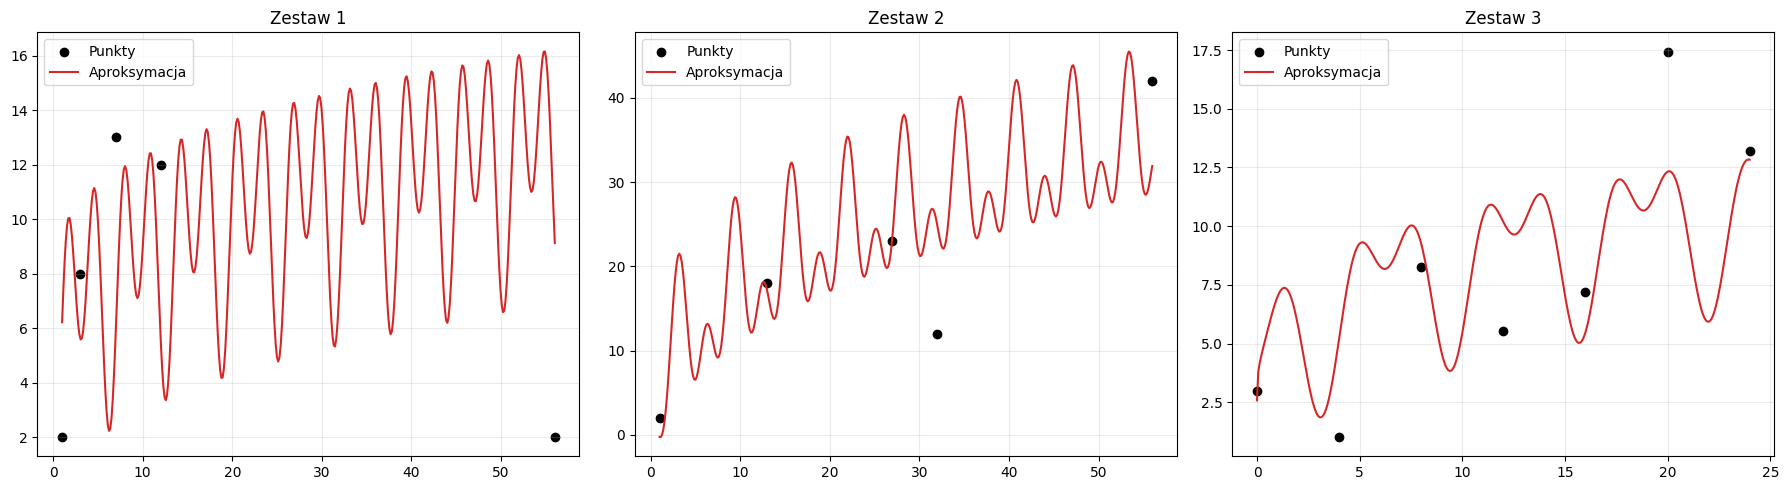

Zestaw 1: a = 7.0747, b = -2.1276, c = 2.3550, MSE = 32.8345
Zestaw 2: a = -10.4336, b = -6.1444, c = 10.4549, MSE = 54.8085
Zestaw 3: a = 3.6229, b = 2.5818, c = 3.0384, MSE = 9.9081


In [4]:
basis_task3 = [
    lambda values: np.sin(values) ** 2,
    np.cos,
    np.cbrt,
]

fig, axes = plt.subplots(1, len(datasets_approximation), figsize=(18, 5))
task3_results = []

for ax, (name, points) in zip(axes, datasets_approximation):
    x = points[:, 0]
    y = points[:, 1]
    coefficients, fitted_values, mse = fit_linear_model(x, y, basis_task3)
    plot_approximation(ax, x, y, coefficients, basis_task3, name)
    task3_results.append((name, coefficients, mse))

plt.tight_layout()
plt.show()

for name, coefficients, mse in task3_results:
    print(
        f'{name}: a = {coefficients[0]:.4f}, b = {coefficients[1]:.4f}, '
        f'c = {coefficients[2]:.4f}, MSE = {mse:.4f}'
    )

### Wnioski
Drugi model korzysta z innego zestawu funkcji bazowych, dlatego mimo tej samej metody obliczeń może prowadzić do wyraźnie innego kształtu krzywej i innego błędu dopasowania.
Składnik z pierwiastkiem stopnia trzeciego rośnie wolniej od składnika kwadratowego, więc lepiej opisuje przypadki, w których trend nie powinien zbyt szybko uciekać dla dużych x.

## Zadanie 4.
Losuję po 30 wartości $x_i$ z przedziału $[-10, 10]$, generuję punkty według zależności $y_i = -0.5x_i^2 + 2x_i + rand(i)$ z szumem z przedziału $[-3, 3]$ i dopasowuję parabolę $y = ax^2 + bx + c$.
Powtarzam doświadczenie wielokrotnie, a następnie porównuję otrzymane współczynniki i ich wartości średnie.

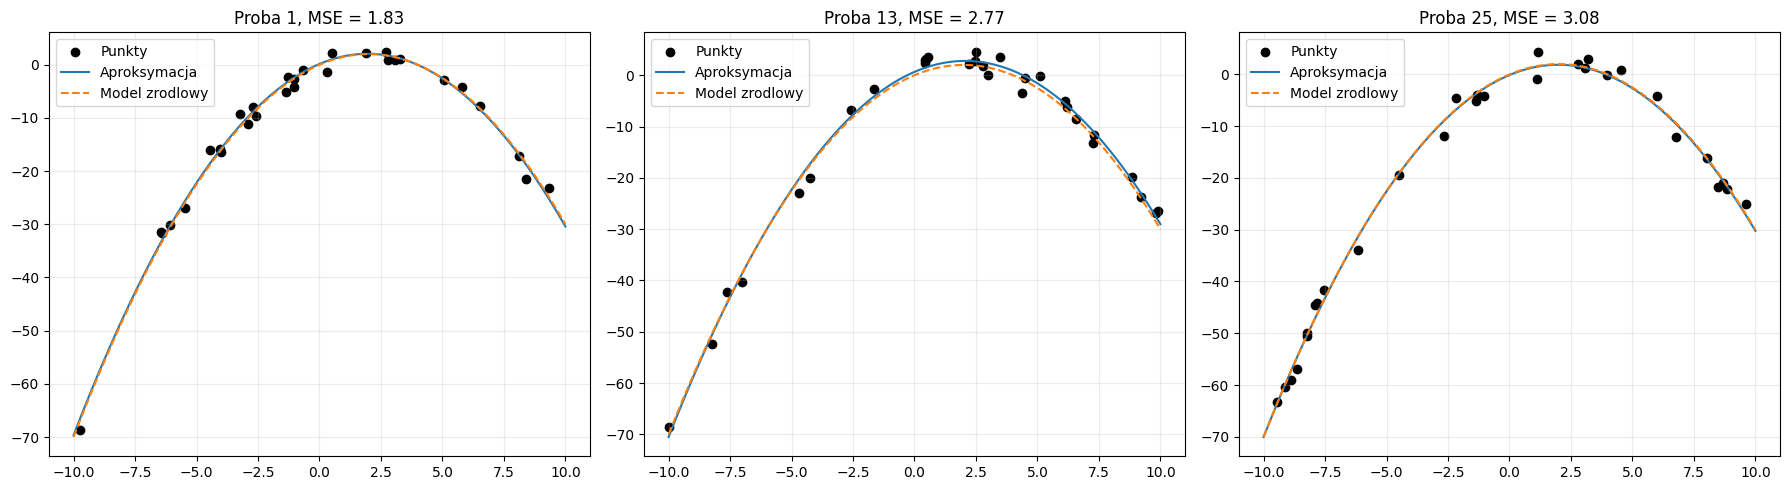

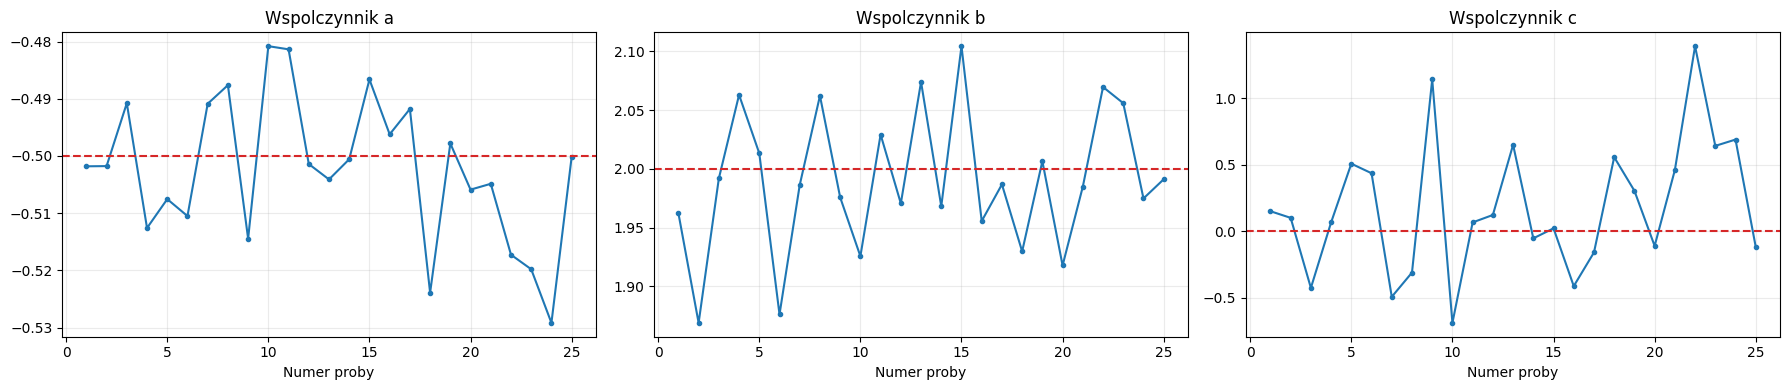

Srednie wspolczynniki: a = -0.5024, b = 1.9898, c = 0.1820
Odchylenia standardowe: a = 0.0125, b = 0.0592, c = 0.4918
Sredni blad MSE: 2.6655
Srednie odchylenie od modelu zrodlowego: a = -0.0024, b = -0.0102, c = +0.1820


In [5]:
def generate_random_parabola_sample(rng: np.random.Generator, sample_size: int = 30) -> tuple[np.ndarray, np.ndarray]:
    """Generuje losowy zbior punktow zgodnie z trescia zadania."""
    x = np.sort(rng.uniform(-10.0, 10.0, size=sample_size))
    noise = rng.uniform(-3.0, 3.0, size=sample_size)
    y = -0.5 * x ** 2 + 2.0 * x + noise
    return x, y


basis_parabola = [
    lambda values: values ** 2,
    lambda values: values,
    lambda values: np.ones_like(values, dtype=np.float64),
]

rng = np.random.default_rng(2026)
trial_count = 25
selected_trials = {0, 12, 24}
trial_coefficients = []
trial_mse = []
selected_samples = []

for trial_index in range(trial_count):
    x, y = generate_random_parabola_sample(rng)
    coefficients, fitted_values, mse = fit_linear_model(x, y, basis_parabola)
    trial_coefficients.append(coefficients)
    trial_mse.append(mse)
    if trial_index in selected_trials:
        selected_samples.append((trial_index + 1, x, y, coefficients, mse))

trial_coefficients = np.vstack(trial_coefficients)
coefficient_means = trial_coefficients.mean(axis=0)
coefficient_stds = trial_coefficients.std(axis=0)
true_coefficients = np.array([-0.5, 2.0, 0.0])

fig, axes = plt.subplots(1, len(selected_samples), figsize=(18, 5))
for ax, (trial_number, x, y, coefficients, mse) in zip(axes, selected_samples):
    dense_x = np.linspace(-10.0, 10.0, 400)
    ax.scatter(x, y, color='black', label='Punkty')
    ax.plot(dense_x, evaluate_linear_model(dense_x, coefficients, basis_parabola), color='tab:blue', label='Aproksymacja')
    ax.plot(dense_x, evaluate_linear_model(dense_x, true_coefficients, basis_parabola), linestyle='--', color='tab:orange', label='Model zrodlowy')
    ax.set_title(f'Proba {trial_number}, MSE = {mse:.2f}')
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.show()

trial_numbers = np.arange(1, trial_count + 1)
parameter_names = ['a', 'b', 'c']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, parameter_name, parameter_values, true_value in zip(axes, parameter_names, trial_coefficients.T, true_coefficients):
    ax.plot(trial_numbers, parameter_values, marker='o', markersize=3)
    ax.axhline(true_value, color='tab:red', linestyle='--')
    ax.set_title(f'Wspolczynnik {parameter_name}')
    ax.set_xlabel('Numer proby')
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

difference = coefficient_means - true_coefficients
print(
    f'Srednie wspolczynniki: a = {coefficient_means[0]:.4f}, b = {coefficient_means[1]:.4f}, '
    f'c = {coefficient_means[2]:.4f}'
)
print(
    f'Odchylenia standardowe: a = {coefficient_stds[0]:.4f}, b = {coefficient_stds[1]:.4f}, '
    f'c = {coefficient_stds[2]:.4f}'
)
print(f'Sredni blad MSE: {np.mean(trial_mse):.4f}')
print(
    f'Srednie odchylenie od modelu zrodlowego: a = {difference[0]:+.4f}, '
    f'b = {difference[1]:+.4f}, c = {difference[2]:+.4f}'
)

### Wnioski
Dla pojedynczej próby współczynniki paraboli zmieniają się przez losowy składnik zakłócający, ale średnie z wielu uruchomień pozostają blisko modelu źródłowego.
Zwiększanie liczby prób stabilizuje ocenę parametrów, bo dodatni i ujemny szum stopniowo się znosi i coraz słabiej przesuwa wartości średnie.